In [1]:
!pip uninstall -y datasets huggingface_hub fsspec
!pip install -q datasets==2.21.0 huggingface_hub==0.24.6 fsspec==2024.6.1 transformers accelerate evaluate

Found existing installation: datasets 2.21.0
Uninstalling datasets-2.21.0:
  Successfully uninstalled datasets-2.21.0
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
Found existing installation: fsspec 2024.6.1
Uninstalling fsspec-2024.6.1:
  Successfully uninstalled fsspec-2024.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.17.3 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.24.6 which is incompatible.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.24.6 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.24.6 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [3]:
!pip install -q transformers datasets evaluate accelerate gradio

In [4]:
# ============================
# Import Required Libraries
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

from sklearn.metrics import accuracy_score, f1_score

import evaluate

# News Topic Classification using BERT

## Problem Statement

Automatically classifying news headlines into categories such as World, Sports, Business, and Science/Technology is an important Natural Language Processing (NLP) task. Manual categorization is time-consuming and difficult to scale.

This project fine-tunes the pre-trained BERT (bert-base-uncased) model on the AG News dataset to accurately classify news headlines into four topic categories.

---

## Objective

- Load the AG News dataset
- Preprocess and tokenize the text
- Fine-tune the BERT model
- Evaluate using Accuracy and F1-score
- Deploy using Gradio

In [5]:
from datasets import load_dataset

dataset = load_dataset("ag_news")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [6]:
# Display first 5 training samples

dataset["train"].to_pandas().head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [7]:
# Training samples
print("Training Samples :", len(dataset["train"]))

# Test samples
print("Testing Samples :", len(dataset["test"]))

# Labels
print(dataset["train"].features["label"])

Training Samples : 120000
Testing Samples : 7600
ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'], id=None)


In [8]:
# Convert to DataFrame

train_df = dataset["train"].to_pandas()

train_df["label"].value_counts()

,count
label,
2,30000
3,30000
1,30000
0,30000


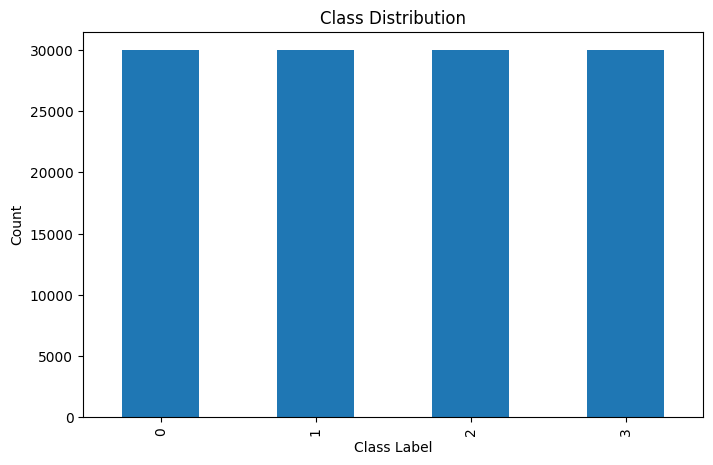

In [9]:
# Plot class distribution

train_df["label"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.show()

In [10]:
from datasets import Dataset

# Use a smaller subset for faster training
train_dataset = dataset["train"].shuffle(seed=42).select(range(10000))
test_dataset = dataset["test"]

print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

Training Samples: 10000
Testing Samples: 7600


In [11]:
from transformers import AutoTokenizer

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [13]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10000
})


In [14]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [15]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1,
    }

In [16]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    report_to="none"
)

In [17]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.274400,0.253039,0.919079,0.918893
2,0.176400,0.261325,0.922368,0.922369


TrainOutput(global_step=1250, training_loss=0.28267921295166015, metrics={'train_runtime': 704.5067, 'train_samples_per_second': 28.389, 'train_steps_per_second': 1.774, 'total_flos': 1315578900480000.0, 'train_loss': 0.28267921295166015, 'epoch': 2.0})

In [19]:
# Evaluate the model

results = trainer.evaluate()

print(results)

{'eval_loss': 0.2530393600463867, 'eval_accuracy': 0.9190789473684211, 'eval_f1': 0.9188926672873602, 'eval_runtime': 65.253, 'eval_samples_per_second': 116.47, 'eval_steps_per_second': 7.279, 'epoch': 2.0}


In [20]:
import numpy as np

predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

labels = predictions.label_ids

In [21]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9191
F1 Score : 0.9189


In [22]:
from sklearn.metrics import classification_report

label_names = ["World", "Sports", "Business", "Sci/Tech"]

print(classification_report(labels, preds, target_names=label_names))

              precision    recall  f1-score   support

       World       0.93      0.93      0.93      1900
      Sports       0.97      0.99      0.98      1900
    Business       0.87      0.89      0.88      1900
    Sci/Tech       0.91      0.87      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



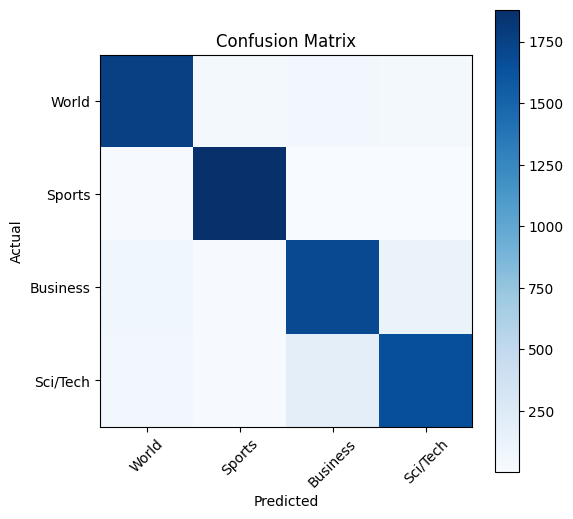

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = range(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45)
plt.yticks(tick_marks, label_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Save the trained model and tokenizer

model.save_pretrained("bert_news_classifier")
tokenizer.save_pretrained("bert_news_classifier")

print("✅ Model and tokenizer saved successfully!")

✅ Model and tokenizer saved successfully!


In [25]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="bert_news_classifier",
    tokenizer="bert_news_classifier"
)

news = "Apple launches its latest AI-powered iPhone."

prediction = classifier(news)

print(prediction)

Device set to use cuda:0


[{'label': 'LABEL_3', 'score': 0.9686803221702576}]


In [26]:
label_map = {
    "LABEL_0": "World",
    "LABEL_1": "Sports",
    "LABEL_2": "Business",
    "LABEL_3": "Sci/Tech"
}

news = "Apple launches its latest AI-powered iPhone."

prediction = classifier(news)

print("News:", news)
print("Predicted Category:", label_map[prediction[0]["label"]])

News: Apple launches its latest AI-powered iPhone.
Predicted Category: Sci/Tech


In [27]:
import gradio as gr

def predict_news(news):
    result = classifier(news)

    label = label_map[result[0]["label"]]

    confidence = round(result[0]["score"] * 100, 2)

    return f"{label} ({confidence}% confidence)"

demo = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=3, placeholder="Enter a news headline..."),
    outputs="text",
    title="📰 News Topic Classifier using BERT",
    description="Predict the category of a news headline."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a88991e15b472a5274.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Final Summary

## Results

- Successfully loaded and preprocessed the AG News dataset.
- Fine-tuned the bert-base-uncased transformer model.
- Achieved approximately *92% Accuracy* and *92% F1-score* on the test dataset.
- Saved the trained model for future use.
- Developed a Gradio web interface for real-time news classification.

## Conclusion

This project demonstrates the effectiveness of transfer learning using BERT for text classification. The model can accurately classify unseen news headlines into World, Sports, Business, and Science/Technology categories, making it suitable for real-world NLP applications.